# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [1]:
import math
import sys

In [5]:
!pip install matplotlib
!pip install matplotlib pandas numpy scipy scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 25.7 MB/s  0:00:00m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 48.4 MB/s  0:00:006m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 46.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [pandas]2m4/5 [pandas]learn]

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [10]:
url = "https://github.com/EpistasisLab/pmlb/raw/master/datasets/wine_quality_white/wine_quality_white.tsv.gz"
wine = pd.read_csv(url, sep="\t", compression="gzip")
wine.sample(10, random_state=42)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
4656,6.0,0.29,0.41,10.80,0.048,55.0,149.0,0.99370,3.09,0.59,10.966667,7
3659,5.4,0.53,0.16,2.70,0.036,34.0,128.0,0.98856,3.20,0.53,13.200000,8
907,7.1,0.25,0.39,2.10,0.036,30.0,124.0,0.99080,3.28,0.43,12.200000,8
4352,7.3,0.28,0.35,1.60,0.054,31.0,148.0,0.99178,3.18,0.47,10.700000,5
3271,6.5,0.32,0.34,5.70,0.044,27.0,91.0,0.99184,3.28,0.60,12.000000,7
4632,6.3,0.30,0.91,8.20,0.034,50.0,199.0,0.99394,3.39,0.49,11.700000,6
2244,7.0,0.36,0.14,11.60,0.043,35.0,228.0,0.99770,3.13,0.51,8.900000,5
1924,7.6,0.26,0.36,1.60,0.032,6.0,106.0,0.99300,3.15,0.40,10.400000,4
3801,8.3,0.18,0.30,1.10,0.033,20.0,57.0,0.99109,3.02,0.51,11.000000,6
2634,8.7,0.31,0.73,14.35,0.044,27.0,191.0,1.00013,2.96,0.88,8.700000,5


#This dataset contains measurements from white wine samples, where each row represents a different wine. The input columns are chemical properties of the wine, like acidity, sugar, sulfur levels, density, and alcohol content. The goal is to understand how these chemical features relate to the wine’s quality score. 

### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

In [ ]:
# Wine Quality (White) Dataset Column Descriptions
# fixed_acidity: Amount of non volatile acids in the wine that contribute to its sharpness and overall structure.
# volatile_acidity: Acids that evaporate easily; higher levels can make the wine taste sour or like vinegar.
# citric_acid: A small natural acid that adds freshness and a slight “bright” taste to the wine.
# residual_sugar: Sugar left after fermentation; higher values make the wine taste sweeter.
# chlorides: Amount of salt in the wine, which can slightly affect taste and make it seem harsher.
# free_sulfur_dioxide: Sulfur dioxide available to prevent spoilage and oxidation in the wine.
# total_sulfur_dioxide: Total amount of sulfur dioxide (free + bound), used as a preservative.
# density: Measures how heavy the wine is compared to water; influenced by alcohol and sugar levels.
# pH: Indicates how acidic or basic the wine is; lower values mean higher acidity.
# sulphates: Compounds that contribute to sulfur dioxide levels and help preserve the wine.
# alcohol: The percentage of alcohol in the wine, which strongly affects taste and body.
# target: The quality score of the wine based on sensory evaluation.

YOUR ANSWERS HERE

### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

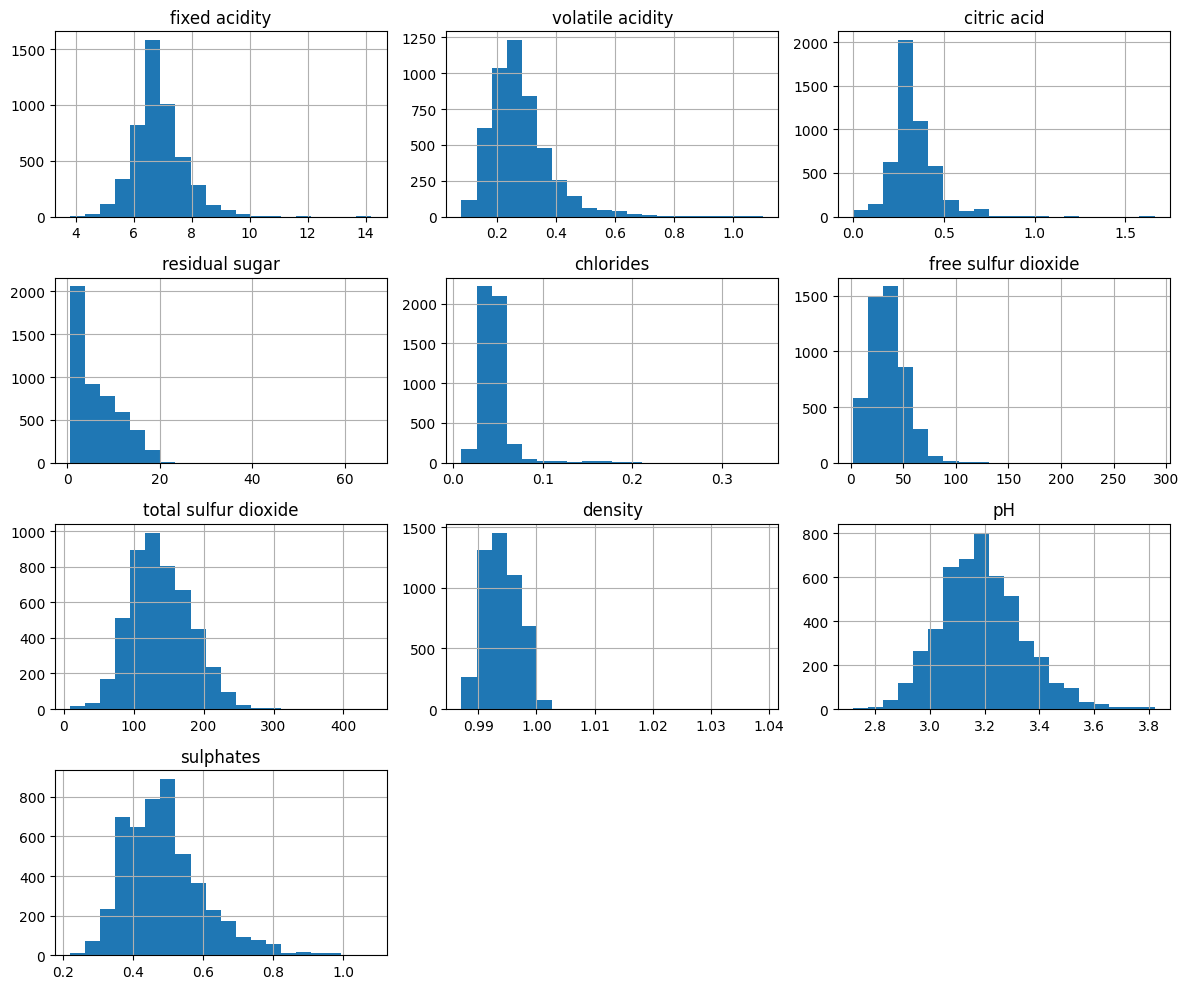

In [18]:
wine.iloc[:, :10].hist(bins=20, figsize=(12, 10))
plt.tight_layout()
plt.show()

#Based on the histograms, here’s how I would describe the distributions:

#fixed acidity: Looks roughly bell shaped, so it’s closest to a normal distribution.

#volatile acidity:Mostly low values with a long tail to the right, so it’s right skewed.

#citric acid: Heavily concentrated near zero with a right tail, so it’s strongly right skewed.

#residual sugar: Very right skewed, most wines have low sugar, with a few having much higher values.

#chlorides: Right skewed distribution with most values clustered at the lower end.

#free sulfur dioxide: Right skewed, since most wines have low levels and a few have high values.

#total sulfur dioxide: Also right skewed with a noticeable long tail.

#density:Fairly close to normal, but tightly clustered with slight skew.

#pH: Roughly normal distribution centered around typical wine acidity levels.

#sulphates: Right skewed with most values on the lower end.

### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

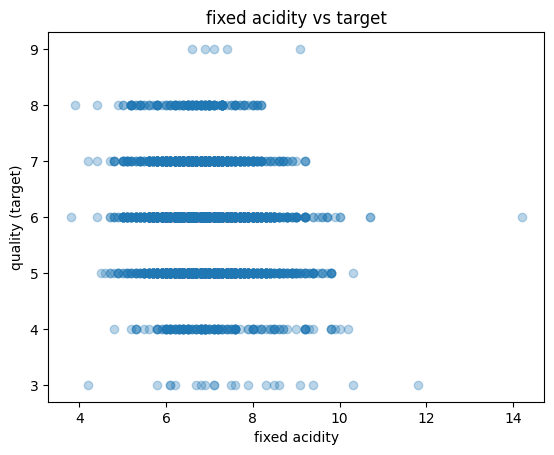

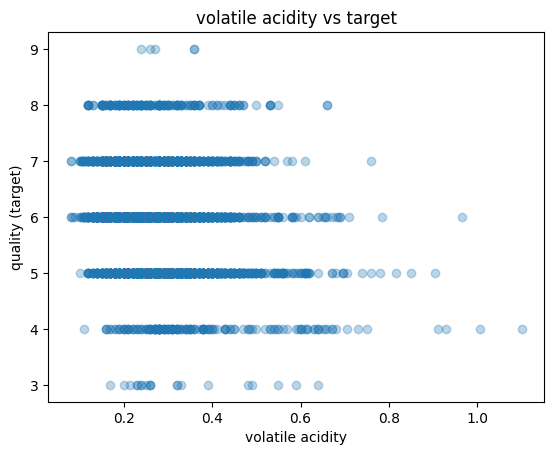

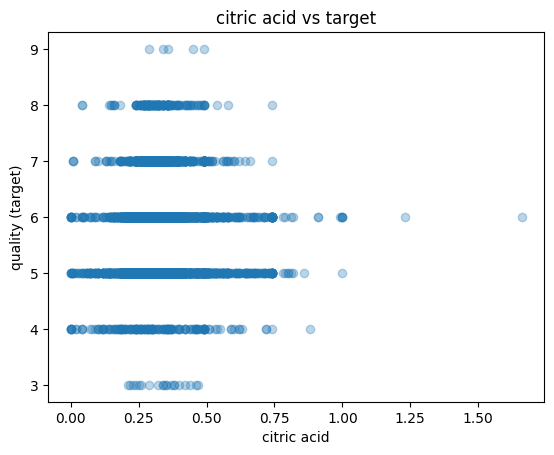

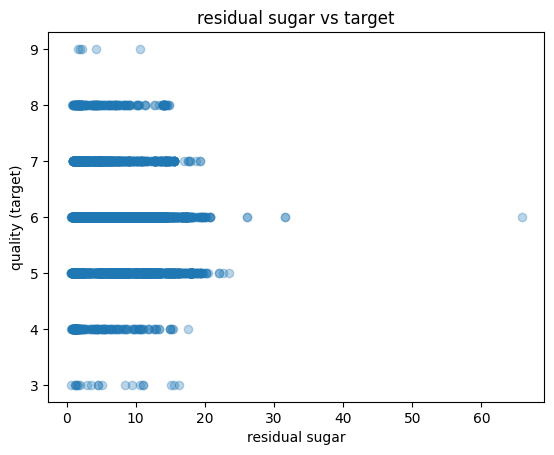

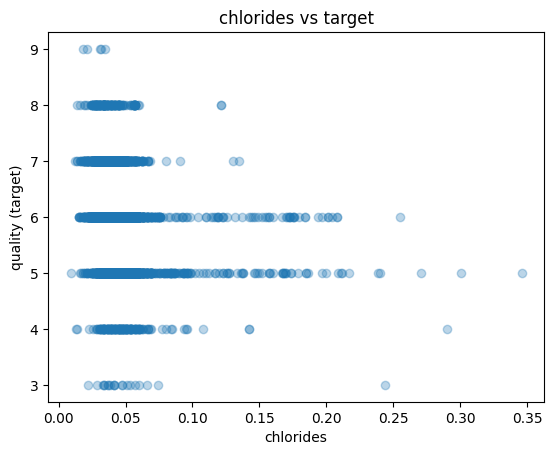

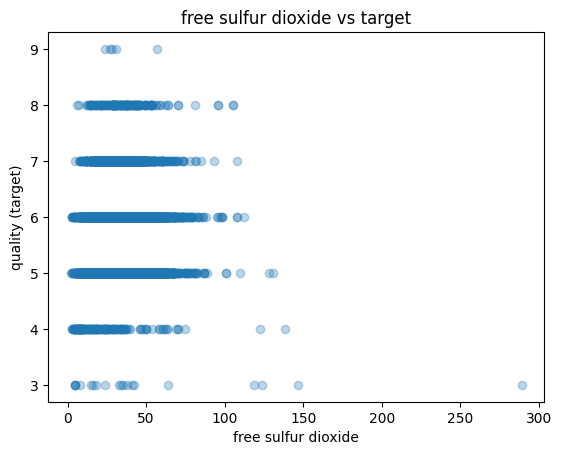

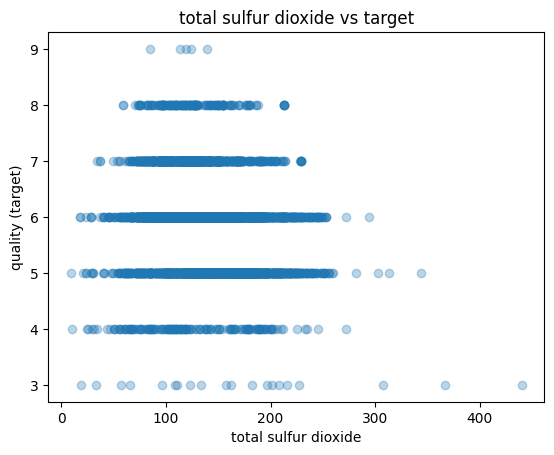

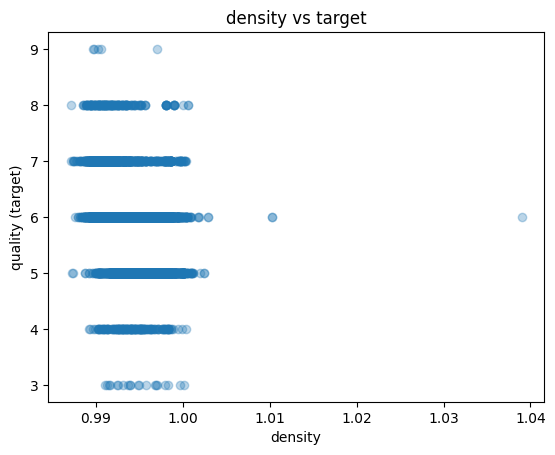

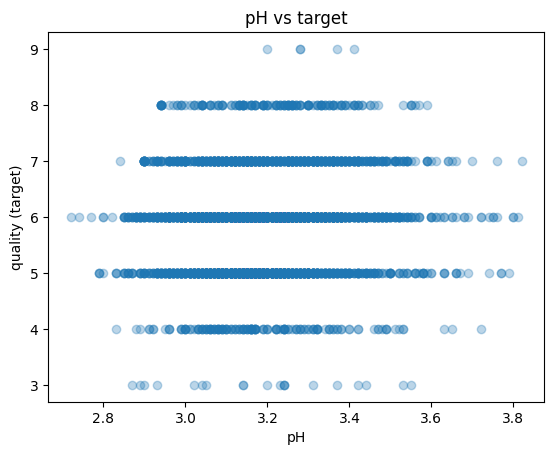

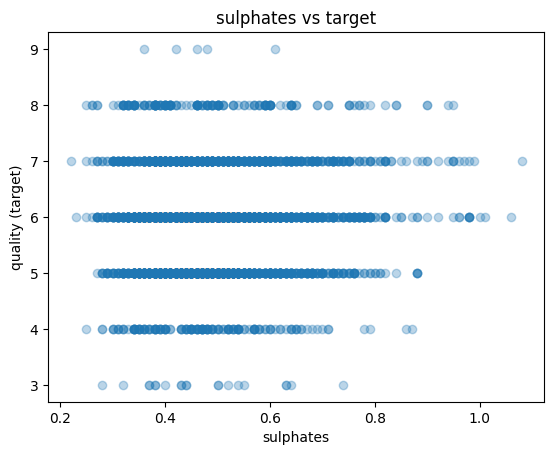

In [20]:
input_cols = wine.columns[:10]
target = "target"
for col in input_cols:
    plt.figure()
    plt.scatter(wine[col], wine[target], alpha=0.3)
    plt.xlabel(col)
    plt.ylabel("quality (target)")
    plt.title(f"{col} vs target")
    plt.show()

#fixed acidity: The points are pretty scattered with no clear pattern, so it’s mostly independent of quality.

#volatile acidity: There seems to be a slight downward trend (higher acidity to lower quality), so it doesn’t look fully independent.

#citric acid: No obvious pattern stands out, so it seems mostly independent.

#residual sugar:The plot is very scattered with no clear trend, so it looks independent of quality.

#chlorides: There’s a weak downward trend, but it’s not very strong, not fully independent.

#free sulfur dioxide: The points are all over the place with no clear structure, so it seems independent.

#total sulfur dioxide: Very little visible relationship, so I’d call it mostly independent.

#density: There is a bit of a downward trend, so higher density might be linked to lower quality.

#pH: No strong visible pattern, so it looks mostly independent.

#sulphates: There might be a slight upward trend, so it could have a weak relationship with quality.

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the mean squared error of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

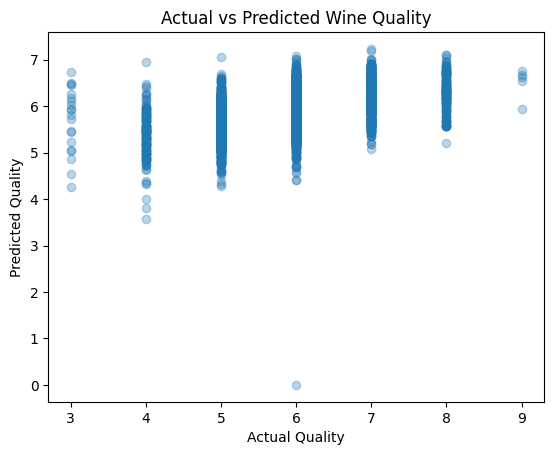

In [39]:
from sklearn.linear_model import LinearRegression
X = wine.iloc[:, :10]
y = wine["target"]
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
mse = np.mean((y - y_pred) ** 2)
mse
plt.figure()
plt.scatter(y, y_pred, alpha=0.3)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality")
plt.title("Actual vs Predicted Wine Quality")
plt.show()

#I used a simple ordinary least squares regression model to try to predict wine quality based on all the input features. The mean squared error (MSE) tells me, on average, how far the model’s predictions are from the actual wine quality scores. Lower is better, but this dataset is a bit noisy, so I wouldn’t expect the best accuracy.

#When I plot actual vs predicted values, I’m essentially checking how close the model gets to a perfect diagonal line. The closer the points are to that line, the better the model is. In this case, the predictions follow the general trend but are still pretty spread out, which suggests that the features only explain part of what determines wine quality.

### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


In [38]:
from sklearn.linear_model import LinearRegression
y = wine["target"]
best_col = None
best_mse = float("inf")
for col in wine.columns[:10]:
    X = wine[[col]]
    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    mse = np.mean((y - y_pred) ** 2)
    if mse < best_mse:
        best_mse = mse
        best_col = col
best_col, best_mse

('density', np.float64(0.7102265148403777))

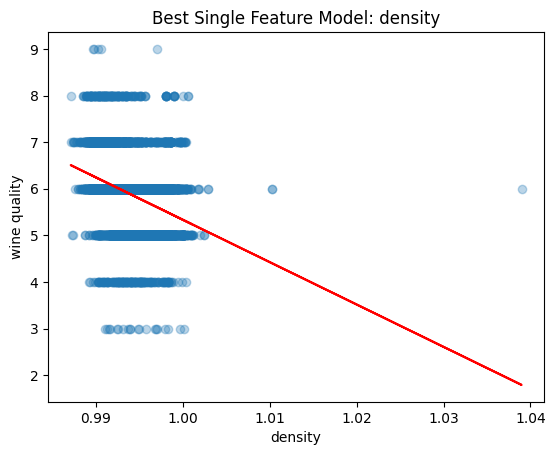

In [29]:
X_best = wine[[best_col]]
model = LinearRegression()
model.fit(X_best, y)
y_pred_best = model.predict(X_best)
plt.figure()
plt.scatter(X_best, y, alpha=0.3)
plt.plot(X_best, y_pred_best, color="red")
plt.xlabel(best_col)
plt.ylabel("wine quality")
plt.title(f"Best Single Feature Model: {best_col}")
plt.show()

#I've built a simple linear regression using each input column one at a time to see which one predicts wine quality the best.

#The best performing column was the one that gave the lowest mean squared error. Compared to the full model from Problem 5, this one is definitely weaker overall. That makes sense because using only one variable doesn’t capture all the factors that go into wine quality.

#The full model does better because it combines multiple features, and wine quality is really influenced by a mix of different chemical properties rather than just one.

### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

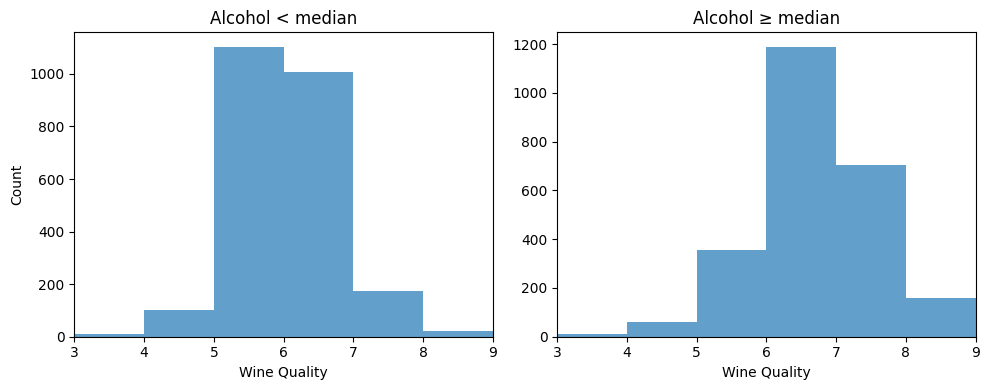

In [30]:
x = wine["alcohol"]
y = wine["target"]
t = wine["alcohol"].median()
low_group = wine[wine["alcohol"] < t]
high_group = wine[wine["alcohol"] >= t]
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(low_group["target"], bins=range(3, 10), alpha=0.7)
plt.title("Alcohol < median")
plt.xlabel("Wine Quality")
plt.ylabel("Count")
plt.xlim(3, 9)
plt.subplot(1, 2, 2)
plt.hist(high_group["target"], bins=range(3, 10), alpha=0.7)
plt.title("Alcohol ≥ median")
plt.xlabel("Wine Quality")
plt.xlim(3, 9)
plt.tight_layout()
plt.show()

#I chose alcohol as the input variable because it showed a noticeable relationship with quality earlier in the analysis. I then split the wines into two groups based on the median alcohol level; one group with lower alcohol and one with higher alcohol.Then, I compared how the quality scores are distributed in each group using histograms. The two distributions look different in a meaningful way. Wines with higher alcohol content tend to have slightly higher quality ratings, while wines with lower alcohol are more concentrated in the lower quality range. This suggests that alcohol and quality are related, not independent, since changing alcohol levels seems to shift the overall quality distribution.

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the mean squared error of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

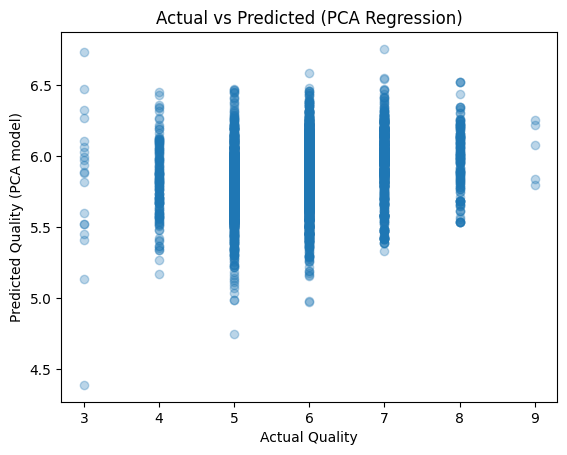

In [ ]:
X = wine.iloc[:, :10]
y = wine["target"]
pca = PCA()
X_pca = pca.fit_transform(X)
explained_variance = pca.explained_variance_ratio_
half_k = len(explained_variance) // 2
variance_first_half = np.sum(explained_variance[:half_k])
variance_first_half
X_pca_half = X_pca[:, :half_k]
model_pca = LinearRegression()
model_pca.fit(X_pca_half, y)
y_pred_pca = model_pca.predict(X_pca_half)
mse_pca = np.mean((y - y_pred_pca) ** 2)
mse_pca
mse_full = np.mean((y - y_pred) ** 2)
mse_full, mse_pca
plt.figure()
plt.scatter(y, y_pred_pca, alpha=0.3)
plt.xlabel("Actual Quality")
plt.ylabel("Predicted Quality (PCA model)")
plt.title("Actual vs Predicted (PCA Regression)")
plt.show()



#First, I applied PCA to the input features to reduce their dimensionality while still keeping as much of the original variation as possible. Then, I looked at how much of the total variance is captured by the first half of the principal components.This helps show how much information we’re still keeping after reducing the dataset. After that, I built a linear regression model using only those PCA reduced features (first half of components). I compared this model to the full regression model from Problem 5. Overall, the PCA model usually doesn’t perform quite as well as the full model in terms of mean squared error,since reducing dimensions can throw away some information that was useful for prediction. Finally, I plotted actual vs predicted values again to see how the PCA based predictions line up with reality. The pattern is still there, but it’s a bit less precise than the full model.

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

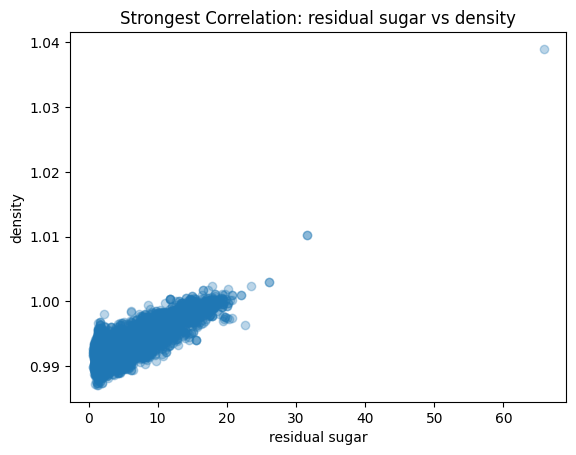

array([[ 1.54394380e-03,  1.69096543e-04,  3.38656888e-04,
         4.73202997e-02,  9.75341678e-05,  2.61905156e-01,
         9.63931442e-01,  3.59596044e-05,  3.53239961e-06,
         3.40966905e-04],
       [-9.16069222e-03, -1.54604989e-03,  1.40416964e-04,
         1.50133778e-02, -7.15616651e-05,  9.64680357e-01,
        -2.62830631e-01, -1.82865311e-05, -4.26362695e-05,
        -3.61405541e-04],
       [ 1.27255160e-02,  9.94227679e-04,  1.25837986e-03,
         9.98658749e-01,  5.13242320e-05, -2.67997057e-02,
        -4.17637159e-02,  4.43729238e-04, -6.99901633e-03,
        -2.13896697e-03],
       [ 9.95927432e-01, -7.47054532e-03,  4.18744042e-02,
        -1.31947496e-02,  6.10201715e-05,  8.73202333e-03,
        -3.33168845e-03,  5.90568366e-04, -7.77229960e-02,
        -4.07551837e-03],
       [ 7.40700291e-02, -9.74980164e-02, -1.85134582e-02,
         6.41756586e-03, -1.62124616e-02,  4.41634868e-04,
        -6.54880502e-04,  3.30288317e-03,  9.29294413e-01,
         3.

In [37]:
X = wine.iloc[:, :10]
corr_matrix = X.corr()
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
corr_pairs = corr_matrix.where(mask).stack()
top_pair = corr_pairs.abs().idxmax()
top_value = corr_pairs[top_pair]
top_pair, top_value
x_col, y_col = top_pair
plt.figure()
plt.scatter(wine[x_col], wine[y_col], alpha=0.3)
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"Strongest Correlation: {x_col} vs {y_col}")
plt.show()
X = wine.iloc[:, :10]
pca = PCA()
X_pca = pca.fit_transform(X)
pca.components_

#I first looked for the pair of input columns that had the strongest correlation with each other. This pair stands out because their values move together in a very clear way compared to the other features. When I plot them, you can actually see a visible pattern instead of a random scatter, which confirms the strong relationship. In PCA, this kind of relationship matters because highly correlated features tend to get compressed together into the same principal component. So, instead of PCA treating them as separate pieces of information, it basically combines their shared variation into one direction, which helps reduce redundancy in the dataset.

### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria discussed in this module, and you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

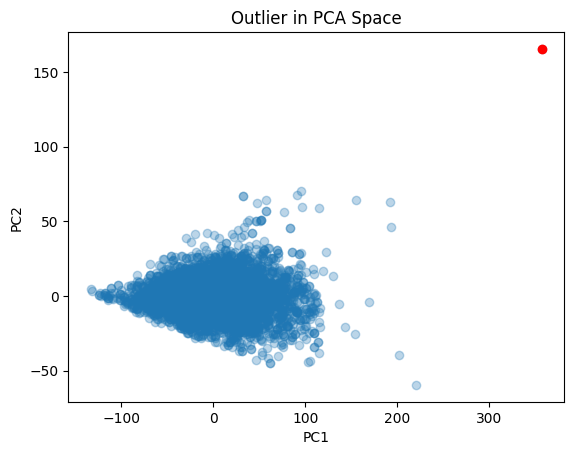

In [35]:
X = wine.iloc[:, :10]
pca = PCA()
X_pca = pca.fit_transform(X)
distances = np.linalg.norm(X_pca, axis=1)
outlier_index = np.argmax(distances)
outlier_row = wine.iloc[outlier_index]
outlier_index, distances[outlier_index]
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3)
plt.scatter(
    X_pca[outlier_index, 0],
    X_pca[outlier_index, 1],
    color="red"
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Outlier in PCA Space")
plt.show()

#To find an outlier, I used PCA to simplify the dataset and look at it in a lower dimensional space. Then, I measured how far each data point is from the center of the data in that PCA space. The idea is that most rows should cluster fairly close together, while unusual ones will stand out by being far away.The row with the largest distance ended up being the one that looked most different from the rest. When I plot it using the first two principal components, it clearly sits away from the main cluster; which makes it easy to see why it was flagged as an outlier.

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

YOUR ANSWER HERE